# 01. 전력계통과 Power Flow 입문

전력계통은 발전기, 부하, 변전소, 송전선이 연결된 거대한 네트워크입니다. Power flow는 이 네트워크에서 **각 bus의 전압 크기와 각도**를 찾는 문제입니다. 전압을 알면 선로 전류, 발전기 출력, 손실, 과부하 여부를 계산할 수 있습니다.

처음 볼 때 중요한 단어는 네 가지입니다.

- **Bus**: 전기적으로 전압 하나로 대표되는 노드입니다.
- **Branch**: bus와 bus를 잇는 선로 또는 변압기입니다.
- **Generator / Load**: 전력을 넣거나 소비하는 장치입니다.
- **Ybus**: 네트워크 연결과 임피던스를 담은 sparse admittance matrix입니다.

Power flow는 보통 비선형 방정식 `S = V * conj(Ybus * V)`를 풉니다. 여기서 `S`는 복소 전력, `V`는 복소 전압입니다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False


In [2]:
case = tu.load_case('case9')
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, branches={case.branch.shape[0]}, ybus_nnz={case.ybus.nnz}")
display(pd.DataFrame([
    {'term': 'Slack bus', 'meaning': '기준 각도를 고정하고 남는 P/Q 불균형을 흡수하는 기준 bus'},
    {'term': 'PV bus', 'meaning': '발전기 bus. P와 |V|를 지정하고 Q와 angle을 찾는다'},
    {'term': 'PQ bus', 'meaning': '부하 bus. P/Q를 지정하고 |V|와 angle을 찾는다'},
    {'term': 'Ybus', 'meaning': 'bus 간 admittance를 모은 sparse matrix'},
    {'term': 'Sbus', 'meaning': '각 bus의 net complex injection, generation minus load'},
]))


case=case9, buses=9, branches=9, ybus_nnz=27


,term,meaning
0,Slack bus,기준 각도를 고정하고 남는 P/Q 불균형을 흡수하는 기준 bus
1,PV bus,발전기 bus. P와 |V|를 지정하고 Q와 angle을 찾는다
2,PQ bus,부하 bus. P/Q를 지정하고 |V|와 angle을 찾는다
3,Ybus,bus 간 admittance를 모은 sparse matrix
4,Sbus,"각 bus의 net complex injection, generation minus..."


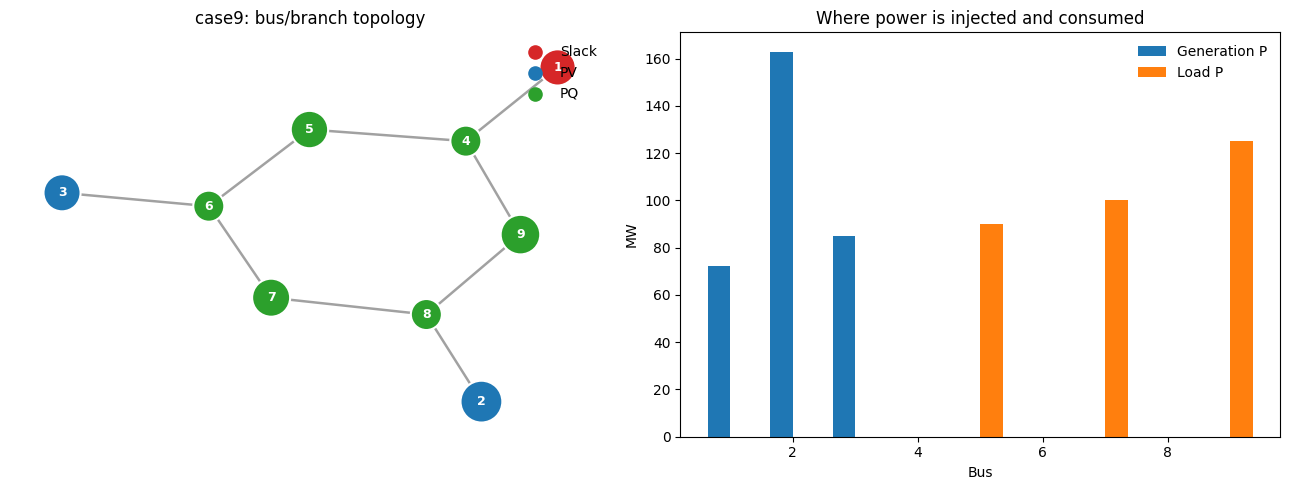

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tu.plot_case_graph(case, axes[0])
tu.plot_power_balance(case, axes[1])
plt.tight_layout()


`case9`는 작아서 topology를 눈으로 볼 수 있습니다. 큰 계통에서는 그림보다 sparse matrix 구조가 더 중요해집니다. 전력계통 계산이 dense matrix가 아니라 sparse matrix 중심으로 흘러가는 이유입니다.


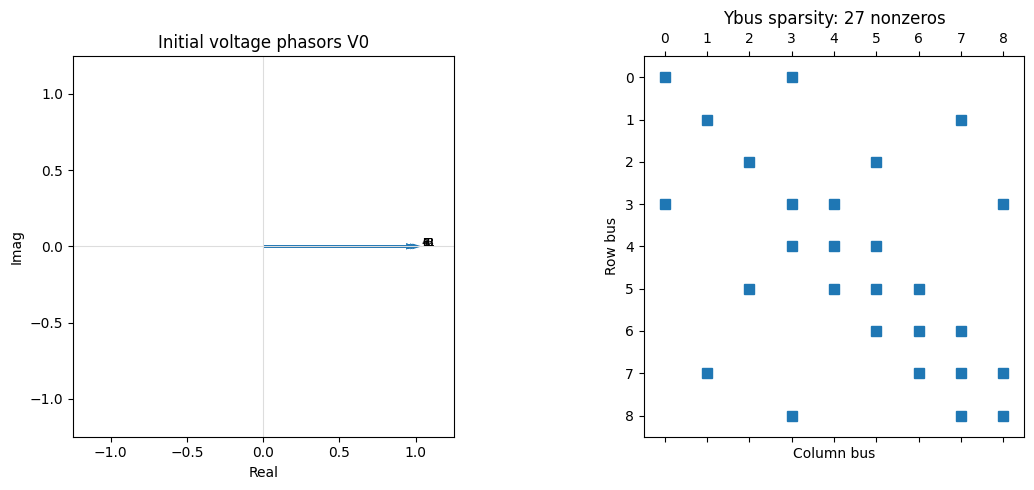

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tu.plot_voltage_phasors(case.v0, axes[0], title='Initial voltage phasors V0')
tu.plot_ybus(case, axes[1])
plt.tight_layout()


Newton-Raphson power flow는 현재 전압 `V`에서 전력 불일치, 즉 **mismatch**를 계산하고, Jacobian으로 보정량을 구해 `V`를 반복 갱신합니다.


converged=True, iterations=4, final_mismatch=1.842e-14


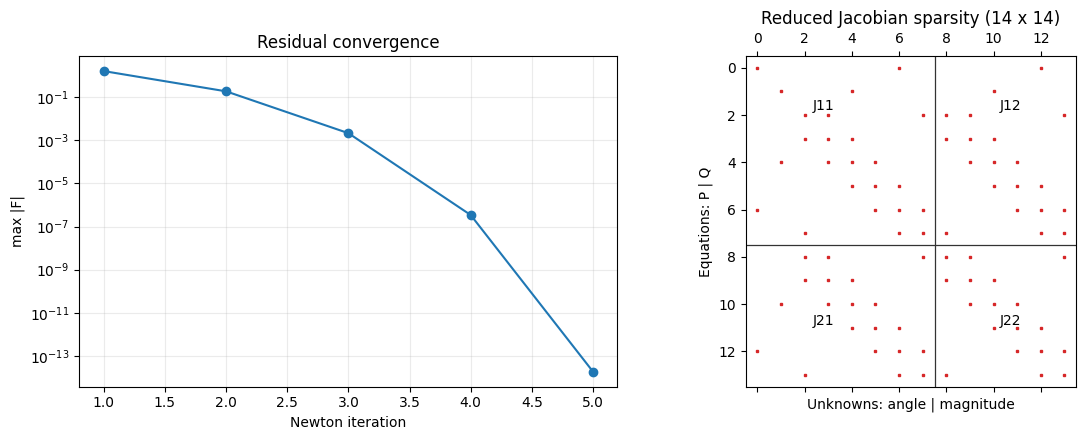

In [5]:
trace = tu.run_newton_with_stage_timing(case)
print(f"converged={trace.converged}, iterations={trace.iterations}, final_mismatch={trace.final_mismatch:.3e}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
tu.plot_convergence(trace, axes[0])
tu.plot_jacobian_blocks(case, trace.voltage, axes[1])
plt.tight_layout()
